<a href="https://colab.research.google.com/github/aa6910/BPhO-Computational-Challenge-2024/blob/main/lecture_4_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python classes

Python classes are pretty important for us as PyTorch implements NNs using objects / classes.

Thankfully, we only need to understand objects/classes at a high-level.  And at a high-level, they are not too bad.

At the highest possible level objects / classes are just containers for:
* state (i.e. data)
* functions that operate on that state (called methods)

What's the difference between an object and a class?
* Objects are a particular container, containing particular state.
* Classes don't actually contain state.  They define the type of state carried by the objects.  The functions/methods operating on the state are defined on the class, then all objects share the same methods.
* There can be many objects belonging to a particular class

Lets drill down into some of these notions.

## The simplest possible class is just a container for state

In [ ]:
#First, we can define the simplest possible class.
#"pass" just indicates that there is nothing in the class.

class SimplestPossibleClass:
    pass

In [ ]:
#Now, we can create 2 objects from the "SimplestPossibleClass"

simple_object1 = SimplestPossibleClass()
simple_object2 = SimplestPossibleClass()

In [ ]:
#These objects act as containers for state.

simple_object1.a = 3
print(simple_object1.a)

simple_object2.b = 2
print(simple_object2.b)

3
2


## How methods are called

So objects acts as containers for state.  But there's much simpler ways of doing that (in Python, the usual approach is `dict`).  Objects let you do much more stuff!

Perhaps the most obvious is that classes let you define methods that operate on the object state.

These methods are just functions that are defined and called in a weird way.

The weird aspects of defining a method are:
* We define a method "inside" the class.
* The first argument in the method definition is the object itself.  This argument is usually named `self`.  You don't have to use the name `self`, but the first argument really does have to be the object itself!

For instance:

In [ ]:
class ClassWithOneMethod:
    def mymethod(self, a, b):
        print(f"State on the object: {self.example_state}")
        print(f"The first argument: {a}")
        print(f"The second argument: {b}")

Now lets initialize a couple of objects, and save some example state



In [ ]:
obj1 = ClassWithOneMethod()
obj2 = ClassWithOneMethod()

obj1.example_state = "red"
obj2.example_state = "blue"

To call a method, we use a bit of a weird syntax.

We don't call a method as if it was a function.

In [ ]:
mymethod(obj1, 1, 2)

NameError: ignored

Instead, we call `mymethod` like,

In [ ]:
obj1.mymethod(1,2)

State on the object: red
The first argument: 1
The second argument: 2


Note that the method definition has three arguments `self, a, b`, while the call has just two arguments `1, 2`.  That's because the object `obj1` is substituted in as the first argument.  So we end up with:
```
self = obj1
a = 1
b = 2
```

## Using methods

Using methods, you can
* modify object state (see `initialize_a` and `increment_a` below).
* use the object state to perform other transformations (see `add_a` below).

Now, we define an `Adder` class, which:
* Stores a number `self.a`.
* Can add that number to an input `add_a`.
* Has a method to initialize `self.a` (`initialize_a`).
* Has a method to increment `self.a` (`increment_a`).


In [ ]:
class Adder:
    def add_a(self, b):
        return self.a + b

    def initialize_a(self, a):
        self.a = a

    def increment_a(self):
        self.a = self.a + 1

In [ ]:
#Initialize a couple of adders.

adder1 = Adder()
adder2 = Adder()

In [ ]:
# We need to make sure `self.a` is defined.  We can do that using the `initialize_a` method,

adder1.initialize_a(4)
adder1.add_a(5)

9

In [ ]:
# But we could also just set self.a "manually",

adder2.a = 6
adder2.add_a(5)

11

In [ ]:
# We can also use methods to modify state.  e.g. we can increment self.a using a method,

print(adder1.add_a(5))
adder1.increment_a()
adder1.add_a(5)

9


10

In [ ]:
# But we could also just manually modify the state,

print(adder2.add_a(5))
adder2.a = adder2.a + 1
adder2.add_a(5)

11


12

## Initializers

Great, so objects act as containers for state and methods.  But initializing that state seems to be super-awkward...

In the previous example, we either had to do:
```
adder = Adder()
adder.initialize_a(2)
```
or
```
adder = Adder()
adder.a = 2
```
This seems like an awful lot of work, especially if we want alot of `Adder`s.

It turns out that we can make initialization much easier, if we use the `__init__` "magic method".

For instance, using `__init__` in `AdderInit` (which is just the same as `Adder`, but where we use an explicit initializer,)

In [ ]:
class AdderInit:
    def __init__(self, a):
        #Just the same as `initialize_a` in
        print("Iniside __init__!!!")
        self.a = a

    def add_a(self, b):
        return self.a + b

    def increment_a(self):
        self.a = self.a + 1

Now, `__init__` is a "magic method" because it changes the behaviour of the class in a funny way.  In this case, `__init__` modifies how the class is created / initialized.  In particular, calling `AdderInit(3)` calls `__init__`:

In [ ]:
adder = AdderInit(3)

Iniside __init__!!!


Though it is important to note that there's nothing special about the code inside `__init__`.  Anything you can do in `__init__`, you could do in a separate non-magic method like `initialize_a`.

Now, `adder.a` has already been set by `__init__` so we don't have to set it "manually"

In [ ]:
print(adder.a)
adder.add_a(6)

3


9

That's great ... but it still treats the objects as a bit of a boring storage for stuff you pass in.  The cool thing is that you can do arbitrary computation inside the initializer.  For instance, we could make a `RandomTranslate` class, which takes vectors as inputs, and translates them by a fixed, but random amount.

Critically, this class should work for 2D, 3D etc. dimensional vectors.

In [ ]:
import torch as t

class RandomTranslate:
    def __init__(self, dim):
        self.translation = t.randn(dim)

    def translate(self, vec):
        return vec + self.translation

In [ ]:
#Now, we can have a random translation for 2D vectors:
random_translate_2Da = RandomTranslate(2)
random_translate_2Da.translate(t.zeros(2))

tensor([-0.5526,  0.9571])

In [ ]:
#If we initialize a second `RandomTranslate` object, it will perform a different random translation
random_translate_2Db = RandomTranslate(2)
random_translate_2Db.translate(t.zeros(2))

tensor([0.3117, 0.2291])

In [ ]:
#Or we can randomly translate for 3D vectors:
random_translate_3D = RandomTranslate(3)
random_translate_3D.translate(t.zeros(3))

tensor([-0.3826,  0.7573,  0.0964])

In [ ]:
#Critically, the random translation is fixed, as the code in `__init__` is run just once, when the object is created, but the code in `translate` is run every time:
print(random_translate_2Da.translate(t.zeros(2)))
a = t.ones(2)
print(random_translate_2Da.translate(a)-a)

tensor([-0.5526,  0.9571])
tensor([-0.5526,  0.9571])


PyTorch neural network layers behave alot like this, because e.g. the weights live inside a class, and they're randomly initialized.

## Making objects behave like functions

If you've got a class like `RandomTranslate`, we kind-of know what its supposed to do: its supposed to translate vectors.  So why do we have to call it like:
```
random_translate_2D.translate(input_vector)
```
Could we instead call `random_translate_2D` as if it was a function:
```
random_translate_2D(input_vector)
```
The answer is yes, if we use more magic methods!  In particular, there's a magic method `__call__`, that tells the object what to do if its called like a function:

In [ ]:
class RandomTranslateFunc:
    def __init__(self, dim):
        self.translation = t.randn(dim)

    def __call__(self, vec):
        return vec + self.translation

In [ ]:
#Now, we can call a RandomTranslateFunc object as if it was a function
random_translate_2D = RandomTranslateFunc(2)
random_translate_2D(t.zeros(2))

tensor([-0.1586,  1.9282])

This turns out to be relevant for NNs in PyTorch.  Specifically, we're going to represent a network / network layer as an object.  And that object represents a function that can be applied to input!

## Subclassing [Non examinable]

Hopefully, everything so far was understandable.  Subclassing is where things get a bit more complex / magical.

Honestly, the usual advice is to avoid subclassing wherever possible.  It tends to make code difficult to follow and messy.  I can't remember the last time I actually used subclassing in my research code...

Unfortunately, PyTorch uses subclassing to define NN modules.  Thankfully, you don't actually have to understand subclassing to define new PyTorch modules: you can just follow the structure of an example, and you'll be fine (which is why this part is non-examinable).

But for those who are interested in thoroughly understanding _everthing_, this may be useful.

In [ ]:
#First lets define an example superclass

class MySuperClass:
    def __init__(self):
        print("Calling MySuperClass __init__")
        self.a = 1

    def superclass_method1(self, x):
        return 2*x

    def superclass_method2(self, x):
        return x+self.a

In [ ]:
#Now lets define an example sub-class.  This class _inherits_ from MySuperClass
#(note the `MySuperClass` in the brackets in the first line of the)

class MySubClass(MySuperClass):
    def __init__(self):
        print("Calling MySubClass __init__")
        self.b = 3
        self.c = 4

    def subclass_method1(self, x):
        return x+self.b

    def subclass_method2(self, x):
        return x+self.c

In [ ]:
#What does inheritance do?  It basically means that we combine all the methods.
#What if methods in sub + superclass have the same name (as for __init__)?
#Then the one on the subclass takes priority.
#That's the case here for __init__: only the __init__ from MySubClass is run.

myobj = MySubClass()
myobj.subclass_method1(3)

Calling MySubClass __init__


6

In [ ]:
#Thus, The methods `sub1.superclass_method1` and `sub1.superclass_method2` exist.

#`sub1.superclassmethod1` just works, because it doesn't rely on any state
myobj.superclass_method1(3)


NameError: ignored

In [ ]:
#But `sub1.superclass_method2` doesn't work because it relies on `self.a`,
#which would usually be set by `MySuperClass`'s initializer `__init__`.
#But remember that initializer hasn't been run, as the subclass overwrote __init__.
myobj.superclass_method2(4)

AttributeError: ignored

In [ ]:
# We can fix this by calling the super-class's initializer inside the sub-class's initializer,
# using the `super().__init__()` line.  (This is a fairly standard bit of Python magic)

class MySubClass2(MySuperClass):
    def __init__(self):
        super().__init__()
        print("Calling MySubClass2 __init__")
        self.c = 3
        self.d = 4

    def subclass_method1(self, x):
        return x+self.c

    def subclass_method2(self, x):
        return x+self.d

In [ ]:
# Now, both initializers are run in sequence, so both
# self.a and self.b are defined on the subclass,
myobj = MySubClass2()
print(myobj.a)
myobj.superclass_method1(3)

Calling MySuperClass __init__
Calling MySubClass2 __init__
1


6

# Neural networks with autodiff

Computing gradients was super-tedious. However, basically the entire point of PyTorch is that it can compute the gradients for you.

Here, we're going to see how that works at the simplest possible level. Later on this week, we'll see how PyTorch gives us a bunch of stuff to make defining and training NNs easier and more convenient.

We're going to consider classification from last week.

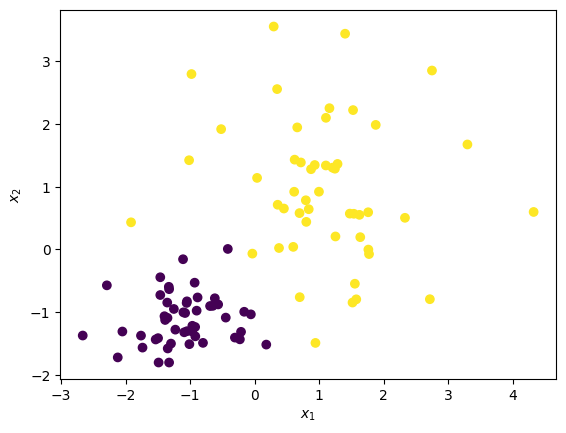

In [ ]:
import torch as t
import matplotlib.pyplot as plt
t.manual_seed(1) #Fix the random seed, so we always generate the same data.

N = 100
x_class_0 = 0.5*t.randn(N//2, 2) - 1
x_class_1 = t.randn(N//2, 2) + 1
X = t.cat([x_class_0, x_class_1], 0)
y = t.cat([t.zeros(N//2, 1), t.ones(N//2, 1)], 0)

plt.scatter(x=X[:, 0], y=X[:, 1], c=y)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

def loss(l):
    return -(y*t.nn.functional.logsigmoid(l) + (1-y)*t.nn.functional.logsigmoid(-l)).sum()

Now, we define our neural network.  We consider a two-layer, relu network (the simplest possible neural net).

In [ ]:
input_features = 2
hidden_features = 100
output_features = 1

#Parameters for the first (input) layer
#This layer takes in_features as input, and returns hidden_features
bias0 = t.randn(hidden_features, requires_grad=True)
weights0 = t.randn(input_features, hidden_features, requires_grad=True)
#Parameters for the second (output) layer
#This layer takes hidden_features as input, and returns out_features
bias1 = t.randn(output_features, requires_grad=True)
weights1 = t.randn(hidden_features, output_features, requires_grad=True)

def net(input):
    """
    Applies our two-layer relu network to the input.
    """
    output_layer0 =  t.relu(input @ weights0 + bias0)
    output_layer1 = output_layer0 @ weights1 + bias1
    return output_layer1



Now, we can apply the network to the inputs, and compute the loss,

In [ ]:
logits = net(X)
print(logits.shape)
L = loss(net(X))
print(L)

torch.Size([100, 1])
tensor(492.4793, grad_fn=<NegBackward0>)


Now, we use PyTorch magic!!!

If we call `.backward()` on the loss, the gradients of the loss magically appear on our parameters!!!

In [ ]:
L = loss(net(X))
L.backward()
print(bias0.grad)

tensor([ 5.8341e+01,  2.0581e-03,  1.4646e+01, -1.0457e-01, -1.3054e+01,
         4.3569e+00,  2.4241e+01, -2.0033e+00,  2.1862e+01, -1.3572e+01,
        -1.0947e+00, -3.6039e+01,  7.3677e+00,  8.5277e+00, -1.7274e+00,
         1.4471e+01,  2.0021e-01,  1.1709e+01,  0.0000e+00, -1.5441e+01,
         5.1520e+01,  6.6555e+01,  4.5029e+01, -5.4565e+01, -3.9082e-02,
         2.8456e+00, -8.3165e+00,  1.2882e+00,  4.1995e+01,  1.2293e-01,
        -2.1401e+00,  1.6725e+00,  1.4932e-01,  1.2550e+01, -1.7333e+00,
         2.8176e+01,  2.1405e+01,  5.1906e+00,  6.0421e+01,  4.8830e-01,
        -1.5666e+01,  1.1257e+01,  5.7653e+00, -3.3895e+01, -2.2109e+01,
         1.0423e+01,  5.0899e+01, -6.9638e-01,  4.0506e-01, -5.1259e+01,
         0.0000e+00, -3.9664e+01,  4.4547e+01, -3.3244e+00, -4.8883e+00,
         2.2761e+01,  6.3023e+01,  4.7666e+00, -6.8900e+01,  5.3867e+01,
        -1.5305e+01,  1.0549e+01,  5.5774e+01, -3.5624e+01,  4.7709e+01,
         1.6861e+01, -2.2341e+00, -3.8171e+01, -9.1

Now, we can use these magically produced gradients to do gradient descent!!!

In [ ]:
learning_rate = 0.0001
for i in range(100):
    L = loss(net(X))
    if 0 == i%10:
        print(L.item())
    L.backward()
    bias0.data.add_(   -learning_rate*bias0.grad)
    weights0.data.add_(-learning_rate*weights0.grad)
    bias1.data.add_(   -learning_rate*bias1.grad)
    weights1.data.add_(-learning_rate*weights1.grad)

    bias0.grad.zero_()
    weights0.grad.zero_()
    bias1.grad.zero_()
    weights1.grad.zero_()


492.4792785644531
18.128040313720703
8.212803840637207
6.339171886444092
5.425164699554443
4.845880031585693
4.432938575744629
4.118199348449707
3.867543935775757
3.6617848873138428


Now, we can plot the resulting decision boundary.  

**Note this code to do the plotting doesn't demonstrate any particulary important concepts and is non-examinable.  (And this holds any other time I use this code to do plotting)**

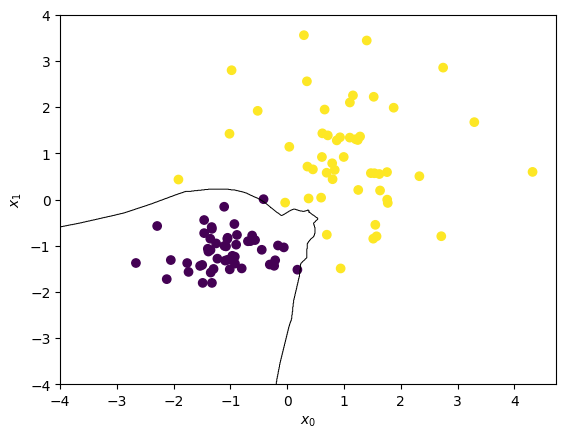

In [ ]:
def plot_decision_boundary(net, X, Y):
    #Non-examinable; just for demonstration purposes.
    x0_grid, x1_grid = t.meshgrid(t.linspace(-4, 4, 1000),
                                  t.linspace(-4, 4, 1000),
                                  indexing="ij")

    X_grid = t.stack([x0_grid, x1_grid], dim=-1)
    c_grid = (0<net(X_grid))[..., 0].detach()

    plt.contour(x0_grid, x1_grid, c_grid, colors='k', linewidths=0.7)
    plt.scatter(X[:,0], X[:,1], c=Y)

    plt.xlabel('$x_0$')
    plt.ylabel('$x_1$')

plot_decision_boundary(net, X, y)


## Neural nets with `torch.nn`
In the last notebook, we saw how you can use autodiff to train a neural network.

However, working with the neural network was kind-of tedious and error prone.  We ended up writing down a big list of all the parameters a bunch of times (e.g. to define an update the parameters).  That's fine in a simple 2-layer network.  But quickly becomes prohibitively painful in deeper networks.

So PyTorch comes with a whole bunch of stuff to make defining and running neural nets easier.
This stuff lives in `torch.nn`.
Importantly, `torch.nn` is _not_ magic in any way, shape or form.
You could implement everything in `torch.nn` pretty straightforwardly (and that's what we're going to see in this notebook).

`torch.nn` represents each network layer (e.g. a linear layer or a relu) as an object.  Which is why you need to make sure you understand the first notebook this week (on classes + objects) thoroughly.  

It turns out that we can define new classes/objects network layers that behave very similarly to the `torch.nn` equivalents.  

PyTorch also uses classes/objects to represent whole networks, and we'll see that too.

However, its pretty important to be able to extend/modify "real" PyTorch `torch.nn` layers.  Unfortunately, PyTorch uses subclassing to add a bunch of advanced bells-and-whistles to network layers that we don't care about.  Specifically, PyTorch layers are all subclasses of `torch.nn.Module`.  While that might sound scary, it actually turns out to not matter much for us.  You can still write a new network layer as an `nn.Module`.  Its very similar to our "plain" object/class equivalents, but with a couple of very minor tweaks.

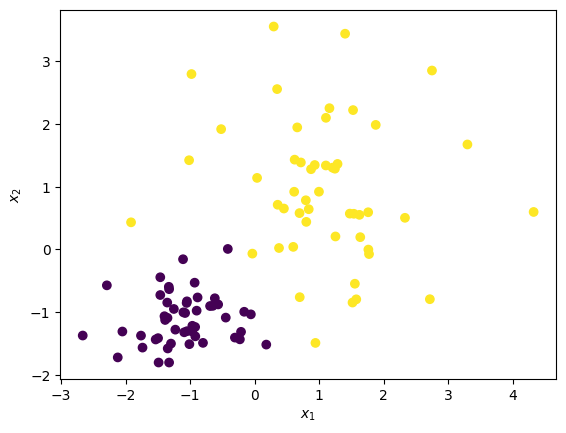

In [ ]:
import torch as t
import matplotlib.pyplot as plt
t.manual_seed(1) #Fix the random seed, so we always generate the same data.

N = 100
x_class_0 = 0.5*t.randn(N//2, 2) - 1
x_class_1 = t.randn(N//2, 2) + 1
X = t.cat([x_class_0, x_class_1], 0)
y = t.cat([t.zeros(N//2, 1), t.ones(N//2, 1)], 0)

plt.scatter(x=X[:, 0], y=X[:, 1], c=y)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

def loss(l):
    return -(y*t.nn.functional.logsigmoid(l) + (1-y)*t.nn.functional.logsigmoid(-l)).sum()

#### Linear Layer

Perhaps the most important kind of layer is the Linear layer.  Once you've understood this layer, the others should be more straightforward.  We use the MyLinear class to represent linear layers.

In [ ]:
class MyLinear():
    def __init__(self, in_features, out_features):
        """
        This function is called when the object (a linear layer) is constructed,
        and initializes the weights and biases to random values.

        We'd construct a new linear layer by calling,
        lin = MyLinear(28*28, 100)
        """
        self.weights = t.randn(in_features, out_features, requires_grad=True)
        self.bias = t.randn(out_features, requires_grad=True)

    def __call__(self, x):
        """
        Defining __call__ allows the object to be called like a function.
        Specifically, we're going to use the linear layer as,
        input = t.randn(batch, 28*28)
        lin = MyLinear(28*28, 100)
        output = lin(input)
        """
        return x @ self.weights + self.bias

    def parameters(self):
        """
        Returns a list of the parameters for this function: useful when trying
        to get all the parameters for the optimizer.
        """
        return [self.weights, self.bias]

In [ ]:
#Now we can construct a linear layer using,
in_features = 3
out_features = 4
batch = 5
lin = MyLinear(in_features, out_features)
#Then we can randomly generate some input,
input = t.randn(batch, in_features)
#And apply the layer to that input,
output = lin(input)
print('Output shape:')
print(output.shape)
#We can also ask for its parameters, and it'll give us a list containing the weights and biases,
print('Parameters:')
print(lin.parameters())

Output shape:
torch.Size([5, 4])
Parameters:
[tensor([[ 0.8662, -0.3528,  0.3482,  1.1371],
        [-0.3339, -1.4724,  0.7296, -0.1312],
        [-0.6368,  1.0429,  0.4903,  1.0318]], requires_grad=True), tensor([-0.5989,  1.6015, -1.0735, -1.2173], requires_grad=True)]


#### ReLU layer

The ReLU layer is much more straightforward, as it doesn't have any parameters, so you don't need to customize the initializer.

In [ ]:
class MyReLU():
    #Doesn't have any parameters, so we don't need __init__.
    def __call__(self, x):
        return t.relu(x)

    def parameters(self):
        #Doesn't have any parameters, so we return an empty list.
        return []

In [ ]:
#Now we can construct a relu layer using,
in_features = 3
batch = 5
relu = MyReLU()
#Then we can randomly generate some input,
input = t.randn(batch, in_features)
#And apply the layer to that input,
print(relu(input))
#We can also ask for its parameters, and it just gives an empty list,
print(relu.parameters())

tensor([[0.6706, 0.0000, 1.5050],
        [0.0000, 1.6169, 0.0000],
        [0.1737, 0.0772, 0.0000],
        [0.0914, 1.3940, 0.0000],
        [0.0000, 0.1924, 0.7161]])
[]


#### Sequential

Now, we need something to bind together the linear layers into a network.
We use the `MySequential` class.
This class contains a list of `MyLinear` and `MyReLU` objects, and applies them in sequence.  Thus, we can use `MySequential` to define the network!

In [ ]:
class MySequential():
    def __init__(self, modules):
        """
        Takes a list of modules ("module" is PyTorch's general term for things
        like linear layers and ReLUs)
        """
        self.modules = modules

    def __call__(self, x):
        """
        Applies each module in sequence.  If we have two modules
        self.modules[1](self.modules[0](x))
        """
        for mod in self.modules:
            x = mod(x)
        return x

    def parameters(self):
        """
        Lists all the parameters in all the modules.
        """
        full_list = []
        for mod in self.modules:
            for param in mod.parameters():
                full_list.append(param)
        return full_list



Now, we can use our objects/classes to define the full network!

Note that its easy to extract all the parameters!

In [ ]:
input_features = 2
hidden_features = 100
output_features = 1
net = MySequential([
    MyLinear(input_features, hidden_features),
    MyReLU(),
    MyLinear(hidden_features, output_features)
])
#Print the shapes of all the parameters
print([p.shape for p in net.parameters()])

[torch.Size([2, 100]), torch.Size([100]), torch.Size([100, 1]), torch.Size([1])]


And we can train the network using,

In [ ]:
learning_rate = 0.0001
for i in range(100):
    L = loss(net(X))
    if 0 == i % 10:
        print(L.item())
    L.backward()

    #Note the difference from the previous notebook;
    #now we have a list of parameters, we can iterate
    #through parameters, rather than having to explicitly
    #do gradient descent + zeroing for each parameter
    #separately
    for param in net.parameters():
        param.data.add_(-learning_rate*param.grad)
        param.grad.zero_()


16.908639907836914
13.61699104309082
11.103324890136719
9.298579216003418
8.05576229095459
7.20871639251709
6.621641635894775
6.200884819030762
5.886841297149658
5.642405033111572


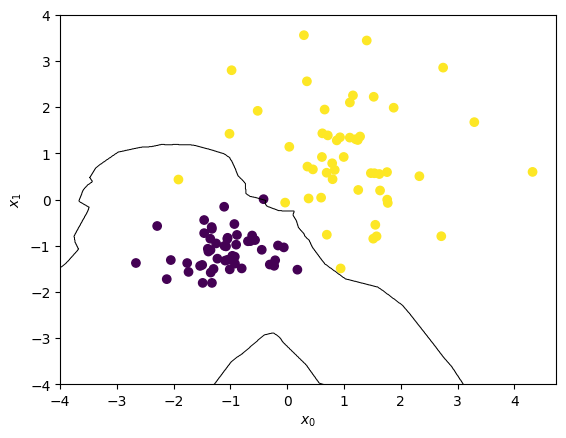

In [ ]:
def plot_decision_boundary(net, X, Y):
    #Non-examinable; just for demonstration purposes.
    x0_grid, x1_grid = t.meshgrid(t.linspace(-4, 4, 1000),
                                  t.linspace(-4, 4, 1000),
                                  indexing="ij")

    X_grid = t.stack([x0_grid, x1_grid], dim=-1)
    c_grid = (0<net(X_grid))[..., 0].detach()

    plt.contour(x0_grid, x1_grid, c_grid, colors='k', linewidths=0.7)
    plt.scatter(X[:,0], X[:,1], c=Y)

    plt.xlabel('$x_0$')
    plt.ylabel('$x_1$')

plot_decision_boundary(net, X, y)

## Using `torch.nn` is almost exactly the same!

`torch.nn` has its own `Linear`, `ReLU` and `Sequential` classes/objects, that you can use directly.

These behave in a very similar way: you can call them on input, and they have a `.parameters()` method:

In [ ]:
import torch.nn as nn

torch_nn_net = nn.Sequential(
    nn.Linear(input_features, hidden_features),
    nn.ReLU(),
    nn.Linear(hidden_features, output_features)
)
#Print the shapes of all the parameters
print([p.shape for p in net.parameters()])

[torch.Size([2, 100]), torch.Size([100]), torch.Size([100, 1]), torch.Size([1])]


There's actually only a couple of differences:
* the `nn.Linear` layer uses a more careful initialization for the random weights.
* you call `nn.Sequential(mod1, mod2, mod3)` (i.e. each module is an argument). In contrast, we called `MySequential([mod1, mod2, mod3])` (i.e. there's one a argument which is a list).  Implementing a function with the `nn.Sequential` behaviour is easy (look up *args if you're interested) but it doesn't really matter for us.

Now, we can train the network

75.43866729736328
49.43085861206055
37.201534271240234
30.30312728881836
25.887290954589844
22.818862915039062
20.56134033203125
18.829362869262695
17.457012176513672
16.341609954833984


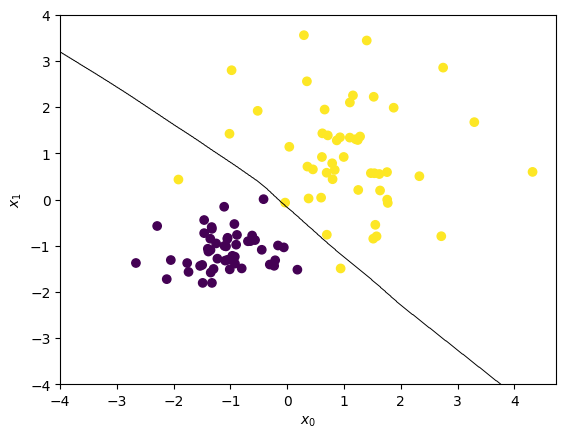

In [ ]:
learning_rate = 0.0001
for i in range(100):
    L = loss(torch_nn_net(X))
    if 0 == i % 10:
        print(L.item())
    L.backward()

    for param in torch_nn_net.parameters():
        param.data.add_(-learning_rate*param.grad)
        param.grad.zero_()

plot_decision_boundary(torch_nn_net, X, y)

## Defining your own torch.nn modules

Most of the time, you'll only need the predefined `torch.nn` modules.  But PyTorch also makes it easy to define your own `torch.nn` modules.

To do this, you need to subclass `nn.Module`.  Which sounds scary, but isn't.

There's one key similarity:
* We set up the state/parameters in `__init__`, exactly as in e.g. our `MyLinear` etc above, and as in a standard classes/objects.

And three key differences:
* We call `super().__init__()` at the start of the initializer.  That sets up some nn.Module magic.
* When we define a parameter in `__init__`, we use e.g. `self.bias = nn.Parameter(t.randn(out_features))`.  That makes sure gradients are computed, and makes sure that `.parameters()` will work.
* To make the module "callable", you define `forward`, rather than `__call__` (as for standard objects and as for e.g. `MyLinear`).

For instance

In [ ]:
class My_torchnn_Linear(nn.Module):
    def __init__(self, in_features, out_features):
        # Calls the nn.Module __init__, which does some setup, so that
        # the convenient stuff around e.g. setting up parameters works.
        super().__init__()

        #Set up the parameters, by wrapping the initial tensors in `nn.Parameter`
        self.weights = nn.Parameter(t.randn(in_features, out_features))
        self.bias = nn.Parameter(t.randn(out_features))

    def forward(self, x):
        return x @ self.weights + self.bias

Additionally, we can define the whole network as a `nn.Module`.  That works because an `nn.Module` can contain other sub-modules,

In [ ]:
class MyNet(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        # Calls the nn.Module __init__, which does some setup, so that
        # the convenient stuff around e.g. setting up parameters works.
        super().__init__()

        self.layer1 = My_torchnn_Linear(input_features, hidden_features)
        self.layer2 = My_torchnn_Linear(hidden_features, output_features)

    def forward(self, x):
        x = self.layer1(x)
        x = t.relu(x)
        x = self.layer2(x)
        return x

(Usually, its easier to use `nn.Sequential`, but this approach allows for more flexibility, which may be useful.  For instance, if you wanted to print the shape of intermediate layer features, then that would be easy here, but hard with `nn.Sequential`).

Now, we can train the resulting network,

77.78964233398438
60.318695068359375
49.1857795715332
41.37501525878906
35.32056427001953
30.929039001464844
27.878448486328125
25.526058197021484
23.625486373901367
22.03910255432129


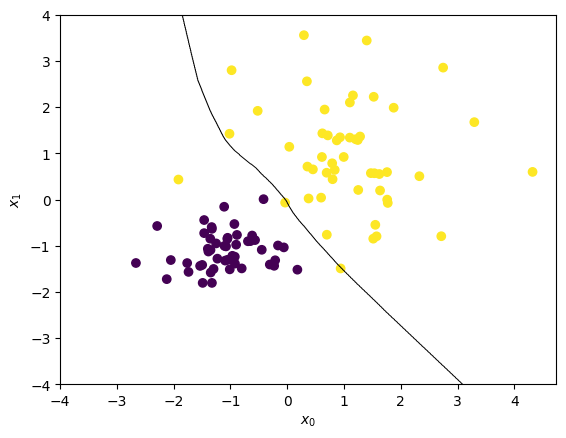

In [ ]:
learning_rate = 0.0001
mynet = MyNet(2, 100, 1)
for i in range(100):
    L = loss(mynet(X))
    if 0 == i % 10:
        print(L.item())
    L.backward()

    for param in mynet.parameters():
        param.data.add_(-learning_rate*param.grad)

    mynet.zero_grad()
plot_decision_boundary(mynet, X, y)

# NN exercises

This notebook basically asks you to re-do stuff in the previous two notebooks.  You should:
* Read the original notebooks.
* Try the exercises here without looking at the original notebooks.
* When you get stuck (everyone gets stuck), try to solve the problem yourself:
  - If you can't remember a function, search for it!
  - If you got an error messages.  What does it mean?  Search for the error message in Google.  Ask [ChatGPT](https://chat.openai.com/) (though ChatGPT can be wrong...).
* For many of the answers, I refer back to the original notebooks.

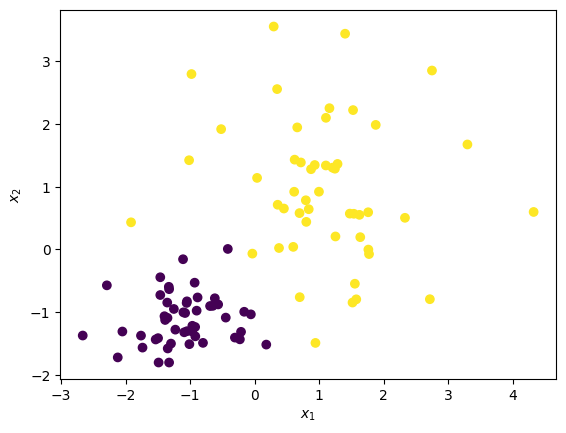

In [ ]:
import torch as t
import matplotlib.pyplot as plt
t.manual_seed(1) #Fix the random seed, so we always generate the same data.

N = 100
x_class_0 = 0.5*t.randn(N//2, 2) - 1
x_class_1 = t.randn(N//2, 2) + 1
X = t.cat([x_class_0, x_class_1], 0)
y = t.cat([t.zeros(N//2, 1), t.ones(N//2, 1)], 0)

plt.scatter(x=X[:, 0], y=X[:, 1], c=y)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

def loss(l):
    return -(y*t.nn.functional.logsigmoid(l) + (1-y)*t.nn.functional.logsigmoid(-l)).sum()

def plot_decision_boundary(net, X, Y):
    #Non-examinable; just for demonstration purposes.
    x0_grid, x1_grid = t.meshgrid(t.linspace(-4, 4, 1000),
                                  t.linspace(-4, 4, 1000),
                                  indexing="ij")

    X_grid = t.stack([x0_grid, x1_grid], dim=-1)
    c_grid = (0<net(X_grid))[..., 0].detach()

    plt.contour(x0_grid, x1_grid, c_grid, colors='k', linewidths=0.7)
    plt.scatter(X[:,0], X[:,1], c=Y)

    plt.xlabel('$x_0$')
    plt.ylabel('$x_1$')

#### Part 1

Define and train a neural network, defining parameters as in Notebook 4.1:
```
bias0 = t.randn(hidden_features, requires_grad=True)
```
At the end, use `plot_decision_boundary(net, X, Y)` to plot your network's predictions.  (Note that for this function to work, you need to be able to apply your network to data using `net(X)`).

In [ ]:
# Your code here

#### Part 2

Define `MyReLU` and `MyLinear` classes.  Use the standard `MySequential class`.

Train the network, and use `plot_decision_boundary(net, X, Y)` to plot the predictions.

In [ ]:
class MySequential():
    def __init__(self, modules):
        """
        Takes a list of modules ("module" is PyTorch's general term for things
        like linear layers and ReLUs)
        """
        self.modules = modules

    def __call__(self, x):
        """
        Applies each module in sequence.  If we have two modules
        self.modules[1](self.modules[0](x))
        """
        for mod in self.modules:
            x = mod(x)
        return x

    def parameters(self):
        """
        Lists all the parameters in all the modules.
        """
        full_list = []
        for mod in self.modules:
            for param in mod.parameters():
                full_list.append(param)
        return full_list


In [ ]:
# Your code here

#### Part 3

Define a neural network using the standard `torch.nn` classes.  Specifically:
* `nn.ReLU`
* `nn.Linear`
* `nn.Sequential`

Train the network, and use `plot_decision_boundary(net, X, Y)` to plot the predictions.

In [ ]:
# Your code here

#### Part 4

Define a neural network using `nn.ReLU` and `nn.Linear`, but _without_ `nn.Sequential`.  Instead, define your own network `MyNet` as a subclass of `nn.Module`.  This gives you more flexibility in how you run the network.  For instance, within `forward`, print the shape of the intermediate layer activations.

Train the network, and use `plot_decision_boundary(net, X, Y)` to plot the predictions.

In [ ]:
# Your code here